This tutorial demonstrates how to train the scorer model to be used in guided diffusion model, including the following step:

1. Download Enamine's Linker Libraries and calculate SA scores
2. Prepare train/val/test set for model training and validation
3. Save the best-performing checkpoint for later use

## Step1: Obtain Industry-grade Linker data from Enamine

We downloaded Stock, Comprehensive, and MADE linkers to database/ENAMINE. For each linker, we calculated synthetic accessibility

+ Source link: https://enamine.net/building-blocks/linkers-for-linkerology
+ Preprocess script: ../../database/get_enamine_database.py
+ Processed file: database/enamine_database.csv



## Step2: Prepare Training data

In order to feed into the Diffusion model, we remove linkers that have invalid atom types, we did that by running the script:

+ python src/precheck_linker_data.py --input ../../database/enamine_database.csv --output data/enamine_clean.csv



In [3]:
with open("../data/enamine_clean_rejection_report.txt", "r") as fin:
    for line in fin.readlines():
        print(line)

REJECTION REPORT




Failure type distribution:

  embedding_failed: 125

  invalid_atoms: ['H', 'H', 'H']: 14

  invalid_atoms: ['H', 'H', 'H', 'H']: 9

  invalid_atoms: ['Si']: 1

  invalid_atoms: ['Na']: 1



Invalid atom types encountered: ['H', 'Na', 'Si']



Next, we removed linkers that appear in PROTAC-DB/PROTACpedia. Finally, we split the non-overlapping data into 5-folds for cross-validation using the following script:

+ python src/process_linker_data.py 

In [4]:
import argparse
import json
from pathlib import Path
from typing import List, Dict, Tuple

import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from rdkit import Chem
from rdkit.Chem import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize

def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        params = rdMolStandardize.CleanupParameters()
        rdMolStandardize.Cleanup(mol)
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)
        Chem.SanitizeMol(mol)
        return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
    except:
        return None


def ecfp4_fingerprint(smi, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    gen = GetMorganGenerator(radius=radius, fpSize=nbits)
    return gen.GetFingerprint(mol)


def max_tanimoto_to_set(fp, fp_set):
    if fp is None or not fp_set:
        return 0.0
    sims = DataStructs.BulkTanimotoSimilarity(fp, fp_set)
    return max(sims) if sims else 0.0

In [8]:
enamine_linkers = {
    "train": "../data/splits/cv_fold_1/train.csv",
    "valid": "../data/splits/cv_fold_1/valid.csv",
    "test": "../data/splits/test_id.csv"
}

df_list = []
for dt, fin in enamine_linkers.items():
    df_list.append(pd.read_csv(fin))
df = pd.concat(df_list, axis=0)
len(df)

23751

In [9]:
df.head()

,ID,SMILES,mw,Group,SA,_nn_tanimoto,scaffold
0,EN300-52600417,[N-]=[N+]=NCC1CC(CO)C1,141.17,Comprehensive,3.428721,0.629630,C1CCC1
1,EN300-9406765,[N-]=[N+]=NCCCCCCCCCCCO,213.32,Comprehensive,2.382600,1.000000,NaN
2,EN300-8588388,[N-]=[N+]=NCCCCCCCCCCO,199.29,Comprehensive,2.414288,1.000000,NaN
3,EN300-7563169,[N-]=[N+]=NCCCCOCCCCO,187.24,Comprehensive,2.636599,0.958333,NaN
4,EN300-9161163,[N-]=[N+]=NCCCN1CCN(CCO)CC1,213.28,Comprehensive,2.486143,0.666667,C1CNCCN1


[18:25:17] Initializing MetalDisconnector
[18:25:17] Running MetalDisconnector
[18:25:17] Initializing Normalizer
[18:25:17] Running Normalizer
[18:25:17] Running Uncharger
[18:25:17] Initializing MetalDisconnector
[18:25:17] Running MetalDisconnector
[18:25:17] Initializing Normalizer
[18:25:17] Running Normalizer
[18:25:17] Running Uncharger
[18:25:17] Initializing MetalDisconnector
[18:25:17] Running MetalDisconnector
[18:25:17] Initializing Normalizer
[18:25:17] Running Normalizer
[18:25:17] Running Uncharger
[18:25:17] Initializing MetalDisconnector
[18:25:17] Running MetalDisconnector
[18:25:17] Initializing Normalizer
[18:25:17] Running Normalizer
[18:25:17] Running Uncharger
[18:25:17] Initializing MetalDisconnector
[18:25:17] Running MetalDisconnector
[18:25:17] Initializing Normalizer
[18:25:17] Running Normalizer
[18:25:17] Running Uncharger
[18:25:17] Initializing MetalDisconnector
[18:25:17] Running MetalDisconnector
[18:25:17] Initializing Normalizer
[18:25:17] Running No

Mean Similarity to PROTAC-DB:0.32


<Axes: >

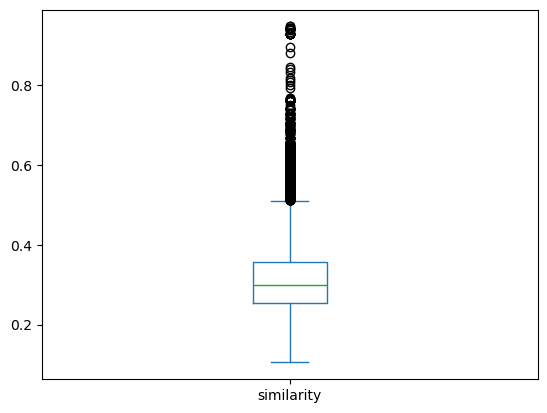

In [15]:
PROTAC_DATA = {
    "protacdb": "../../database/protacdb_database.csv",
    "protacpedia": "../../database/PROTACpedia_database.csv"
}

linker_smiles = []
for name, path in PROTAC_DATA.items():
    protac_df = pd.read_csv(path)
    if name == "protacdb":
        protac_df = protac_df.dropna(subset=["linker_smiles"])
        linker_smiles.extend(protac_df["linker_smiles"].unique())
    #elif name == "protacpedia":
    #    protac_df = protac_df.dropna(subset=["Linker"])
    #    linker_smiles.extend(protac_df["Linker"].unique())
    
linker_smiles = [canonicalize_smiles(s) for s in linker_smiles]
linker_smiles = [s for s in linker_smiles if s]
linker_fps = [ecfp4_fingerprint(s) for s in linker_smiles]
linker_fps = [fp for fp in linker_fps if fp is not None]
    
sim_scores = []
keep_mask = []
for smi in df["SMILES"].tolist():
    fp = ecfp4_fingerprint(smi)
    max_sim = max_tanimoto_to_set(fp, linker_fps)
    sim_scores.append(max_sim)

print(f"Mean Similarity to PROTAC-DB:{np.mean(sim_scores):.2f}")
sim_df = pd.DataFrame({"similarity":sim_scores})
sim_df['similarity'].plot(kind="box")

[18:26:19] Initializing MetalDisconnector
[18:26:19] Running MetalDisconnector
[18:26:19] Initializing Normalizer
[18:26:19] Running Normalizer
[18:26:19] Running Uncharger
[18:26:19] Initializing MetalDisconnector
[18:26:19] Running MetalDisconnector
[18:26:19] Initializing Normalizer
[18:26:19] Running Normalizer
[18:26:19] Running Uncharger
[18:26:19] Initializing MetalDisconnector
[18:26:19] Running MetalDisconnector
[18:26:19] Initializing Normalizer
[18:26:19] Running Normalizer
[18:26:19] Running Uncharger
[18:26:19] Initializing MetalDisconnector
[18:26:19] Running MetalDisconnector
[18:26:19] Initializing Normalizer
[18:26:19] Running Normalizer
[18:26:19] Running Uncharger
[18:26:19] Initializing MetalDisconnector
[18:26:19] Running MetalDisconnector
[18:26:19] Initializing Normalizer
[18:26:19] Running Normalizer
[18:26:19] Running Uncharger
[18:26:19] Initializing MetalDisconnector
[18:26:19] Running MetalDisconnector
[18:26:19] Initializing Normalizer
[18:26:19] Running No

Mean Similarity to PROTACpedia:0.25


<Axes: >

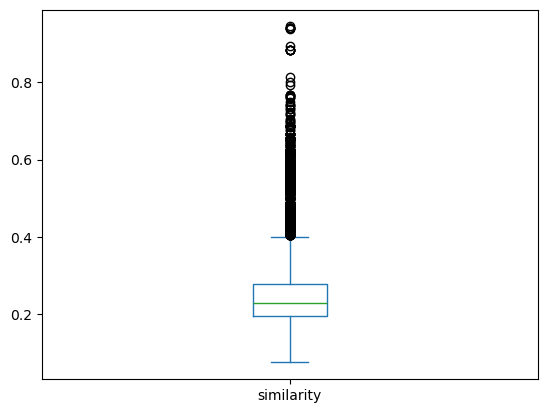

In [16]:
PROTAC_DATA = {
    #"protacdb": "../../database/protacdb_database.csv",
    "protacpedia": "../../database/PROTACpedia_database.csv"
}

linker_smiles = []
for name, path in PROTAC_DATA.items():
    protac_df = pd.read_csv(path)
    if name == "protacdb":
        protac_df = protac_df.dropna(subset=["linker_smiles"])
        linker_smiles.extend(protac_df["linker_smiles"].unique())
    elif name == "protacpedia":
        protac_df = protac_df.dropna(subset=["Linker"])
        linker_smiles.extend(protac_df["Linker"].unique())
    
linker_smiles = [canonicalize_smiles(s) for s in linker_smiles]
linker_smiles = [s for s in linker_smiles if s]
linker_fps = [ecfp4_fingerprint(s) for s in linker_smiles]
linker_fps = [fp for fp in linker_fps if fp is not None]
    
sim_scores = []
keep_mask = []
for smi in df["SMILES"].tolist():
    fp = ecfp4_fingerprint(smi)
    max_sim = max_tanimoto_to_set(fp, linker_fps)
    sim_scores.append(max_sim)

print(f"Mean Similarity to PROTACpedia:{np.mean(sim_scores):.2f}")
sim_df = pd.DataFrame({"similarity":sim_scores})
sim_df['similarity'].plot(kind="box")

+ The average similarity between Enamine linker and PROTAC-DB linkers is 0.32, so there is no data leakage when applying the scorer model to DiffPROTACs diffusion model
+ The average similarity between Enamine linker and PROTACpedia linkers is 0.25, so the scorer generalize to unseen data

## Step3: 

Training pipeline for the SA Scorer GNN on Enamine Linker Data

In [18]:
from pathlib import Path
import subprocess, sys

src_dir = Path.cwd().resolve()
scorer_root = src_dir.parent 
data_dir = scorer_root/"data"/"splits" #isilon/ytang4/protac_design/glue/scorer/data/splits
ckpt_dir = scorer_root/"checkpoints" 
out_dir = scorer_root/"outputs/train_results"

Run 5x Cross-Validation to tune hyperparameters and select best configuration

In [ ]:
training_script = src_dir/"train_sa_score_model.py"

gpu = 0
seed = 42

cmd = [sys.executable, "-u", str(training_script),
    "--gpu", str(gpu),
    "--seed", str(seed),
    "--num_folds", "5"]

print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True, cwd = str(scorer_root))

print("\nTraining Plot Saved to", out_dir/"cv_results.png")

After model selection, re-train on the combined training and validation dataset and run test evaluation. Save model checkpoint.


In [ ]:
training_script = src_dir/"train_sa_score_model.py"

gpu = 4
seed = 42

merged_csv = data_dir/"train_val_merged.csv"
test_pt = data_dir/"test_id.pt"
checkpoint_name = "best_ckpt" 

cmd = [
    sys.executable, str(training_script),
    "--gpu", str(gpu),
    "--seed", str(seed),
    "--train_merged",
    "--merged_csv", str(merged_csv),
    "--test_pt", str(test_pt),
    "--checkpoint_name", checkpoint_name,
    ]

print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True, cwd = str(scorer_root))

print("\nCheckpoint saved to", ckpt_dir / f"{checkpoint_name}.pt")